# Basic setup for every notebook

The following setup ensures that all notebooks:

- use the same imports
- correctly resolve project paths
- automatically reload `.py` module changes
- support exporting figures and tables for the paper

> [!NOTE]
> In case we need to write special functions, classes, etc., it may be beneficial to write them separately in a `.py` file.
> These files should be saved in the `/src` folder.

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))

import pandas as pd
import matplotlib.pyplot as plt 
import yfinance as yf
from src.utils.export import save_figure, save_table

# Keeping changes in the '.py' files synced with the notebook
%load_ext autoreload
%autoreload 2


## Organizing tables and figures

To keep outputs organized and reproducible, figures and tables should always be exported using the helper functions below.

This automatically stores:
- figures in [`paper/figures`](../paper/figures) using the function `save_figure`
- tables in [`paper/tables`](../paper/figures) using the function `save_table`

which keeps the paper-writing workflow synchronized with the analysis notebooks.

```python
# Create some figure with matplotlib
fig, ax = plt.subplots(...)
save_figure(fig, "figure1") # saves the figure to the correct folder

# The same can be done with tables (e.g. Pandas DataFrames)
df = pd.DataFrame(...) # Create some dataframe (df)
save_table(df, "table1")
```

In [3]:
# Example: Downloading yfinance stock data 
stock_data = yf.download(['MSFT', 'AAPL', 'GOOG'], period='1mo')
stock_returns = stock_data.Close.pct_change()

[*********************100%***********************]  3 of 3 completed


In [4]:
# We can create a table
stock_returns.head()

Ticker,AAPL,GOOG,MSFT
2026-05-26,NaN,NaN,NaN
2026-05-27,0.008173,-0.000026,-0.008076
2026-05-28,0.005340,0.003352,0.034701
2026-05-29,-0.001440,-0.025096,0.054451
2026-06-01,-0.018426,-0.010228,0.022832


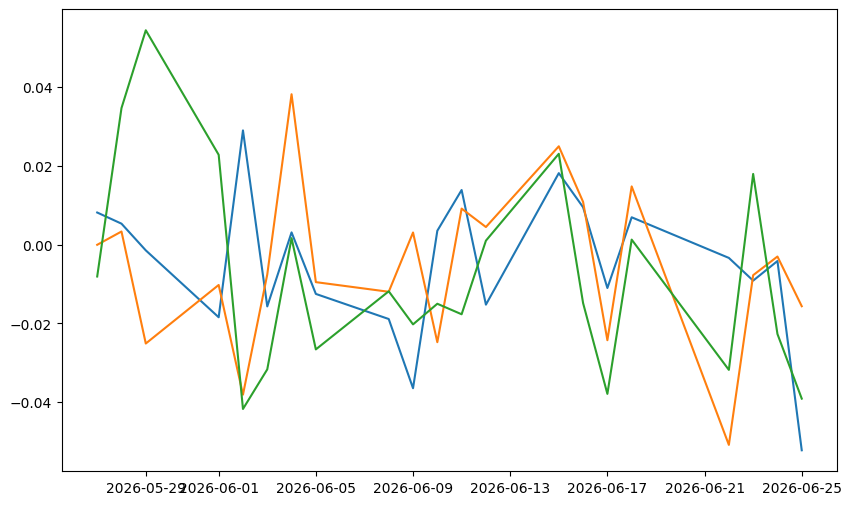

In [5]:
# And a small graph
x = stock_returns.index
y = stock_returns[["AAPL", "GOOG", "MSFT"]]
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x, y)

In [6]:
# We can save both the table and the figure
save_table(stock_returns.head(), "demo_table")
save_figure(fig, "demo_plot")

Table: demo_table saved to: /Users/angelo/Desktop/Studium/SS2026/Data_Science_in_Finance/Paper/Data-Science/paper/tables/demo_table.tex
Figure: demo_plot saved to: /Users/angelo/Desktop/Studium/SS2026/Data_Science_in_Finance/Paper/Data-Science/paper/figures/demo_plot.pdf


## Recommended workflow

- Use notebooks for experimentation and analysis
- Move reusable logic into the `src/` directory
- Export figures/tables directly into the `paper/` folder
- Keep the LaTeX paper synchronized with notebook outputs